# BO Overview and Tutorial

This notebook serves as an overview of the capabilities of the ProCatModel class. This notebook specifically goes over how to use the Bayesian optimization portion of the class to optimize control programs. All of the examples below use a simple A<->B reaction network.

In [1]:
# Import necessary packages
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from pyomo.environ import SolverFactory, value

# Import ProCatModel package
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('ProCatPy'), '..'))
sys.path.insert(0, parent_dir)
from ProCatPy.ProCatSystem import ProCatModel

# Disable warnings due to GP model standardization differences
import warnings
warnings.filterwarnings("ignore")

C:\Users\jflory\AppData\Local\anaconda3\envs\CatEnvBackup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


To begin with, let's define our necessary parameters as well as ensure our results are reproducable. For this tutorial, we will only use a single basis function for simplicity. 

In [2]:
seed = 7
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# Establish baseline energy params
ebounds = np.array([0.8,2])
BEParams = np.array([[2],
                     [1.4]])
EaParams = np.array([[0.6],
                     [1]])

# Define our signal shape parameters
ns = 1
nx = 3*ns+1

# Define our signal parameter limits (remember, frequency bounds are log-scaled)
Amp = ebounds[1]-ebounds[0]
xL = np.array([-Amp, 0, -4, ebounds[0]])
xU = np.array([ Amp, 1, 4, ebounds[1]])

# Define how many old and new experiments to conduct
ntrain = 10
nnew = 10

# Set up tracking variables
Xdata = torch.zeros(ntrain+nnew,nx)
ydata = torch.zeros(ntrain+nnew)
Xbest = torch.zeros(nx)
ybest = torch.zeros(1)

First, lets call our ProCatModel and set our BO and program parameters.

In [3]:
dcn = ProCatModel(BEParams,EaParams)
dcn.SetBOParams(ntrain,nnew,xL,xU)
dcn.SetEnergyParams(ebounds,ns,'Square')

Now, let's generate some initial data to train our GP model.

In [4]:
Xtrain = dcn.GenX()
ytrain = torch.zeros(ntrain,1)

for i in range(ntrain):
    dcn.SetSignalParams(Xtrain[i,:],False)
    dcn.solveBVP(100)
    ytrain[i] = dcn.calc_TOF(dcn.CBg)

model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.11.1\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.11.1\x3a Converged to a locally infeasible
      point. Problem may be infeasible.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.11.1\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


With this initial training data, now we can train a GP model.

In [5]:
dcn.SetData(Xtrain,ytrain)
dcn.trainGP()

Now we can use this model to find which experiment is best to conduct next.

In [6]:
x_rec = dcn.GetRec('UCB',2,False)

print(f'Next Experiment| Amplitude: {x_rec[0,0].numpy():3.2f} Duty Cycle: {x_rec[0,1].numpy():3.2f} Frequency: {x_rec[0,2].numpy():3.2e} Offset: {x_rec[0,3].numpy():3.2f}')

Next Experiment| Amplitude: -0.79 Duty Cycle: 0.33 Frequency: 1.12e+02 Offset: 1.24


Let's conduct this experiment, collect the avTOF results, and add it to the data pool.

In [7]:
dcn.SetSignalParams(x_rec,False)
dcn.solveBVP(100)
y_rec = dcn.calc_TOF(dcn.CBg)
dcn.AddData(x_rec,y_rec)

With all of these individual steps completed, we are now ready to combine them into a fully automated BO loop. This loop will persist until $nnew$ experiments are conducted.

In [8]:
dcn.SetData(Xtrain,ytrain)

for i in range(nnew):
    # Update GP
    dcn.trainGP()

    # Get next point
    x_rec = dcn.GetRec('UCB',2,False)
    #print(x_rec)

    # Simulate new point
    dcn.SetSignalParams(x_rec,False)
    dcn.solveBVP(100)
    y_rec = dcn.calc_TOF(dcn.CBg)

    # Update Dataset
    dcn.AddData(x_rec,y_rec)

    # Record new point selected
    Xdata = dcn.X
    ydata = dcn.y.reshape(-1)

model.name="unknown";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.11.1\x3a Maximum Number of Iterations
      Exceeded.
model.name="unknown";
    - termination condition: infeasible
    - message from solver: Ipopt 3.11.1\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


Let's plot the results of these simulations. Remember, BO looks to both explore new areas and exploit well-performing areas, so although individual simulations may not always show improvement overtime performance will converge.

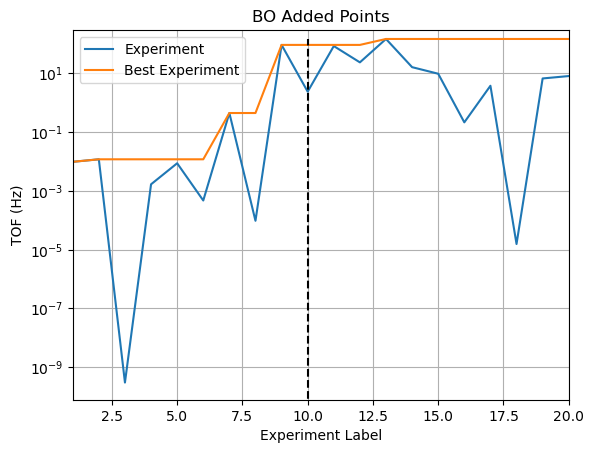

In [10]:
# Process results to discover best performance
ybest = torch.max(ydata)

best_list = torch.zeros(ntrain+nnew)
for i in range(0,ntrain+nnew):
    best_list[i] = torch.max(torch.cat([ydata[:i+1]]))

# Plot BO Results
fig, ax = plt.subplots()
ax.semilogy(range(1,ntrain+nnew+1),ydata)
ax.semilogy(range(1,ntrain+nnew+1),best_list)
ax.plot([ntrain,ntrain],[0,ybest], 'k--')
ax.set_title('BO Added Points')
ax.set_xlabel('Experiment Label')
ax.set_ylabel('TOF (Hz)')
ax.set_xlim([1,ntrain+nnew])
ax.set_ylim([0,2*ybest])
ax.legend(['Experiment','Best Experiment'])
ax.grid()

Here we can 